# Gabor Noise Tiling with Progressive Seam Blur

This notebook demonstrates how to create a large, varied texture by tiling many
Gabor noise renders together. Each tile uses the same trained model but with small
Gaussian perturbations added to the parameters, producing visually distinct but
coherent patches. Tiles are laid out with **zero overlap** and the seams are
dissolved by a **progressive Gaussian blur**: we run several passes that blur a
growing band around each seam line with an increasingly large kernel
(size 3, 5, 7, ... and growing sigma), so the blend zone extends outward from the
seam rather than being a single fixed-width blur.

## Pipeline

1. Load a trained `GaborModel` from checkpoint
2. For each cell in an N x M grid, add Gaussian noise to all 7 parameter tensors
3. Render each variation using `render_gabor_image`
4. Place tiles on the canvas with 0 overlap (edge to edge)
5. Run the progressive Gaussian seam blur over N iterations
6. Display individual tiles and the final stitched result


In [1]:
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

import gabor_noise_renderer as gnr
from gabor_noise_renderer import (
    GaborModel,
    render_gabor_image,
)

torch.manual_seed(42)
np.random.seed(42)

print(f"device: {gnr.device}")

device: cuda


## 1. Configuration

All tuneable knobs live here so the rest of the notebook stays clean.

In [2]:
# --- grid dimensions ---
GRID_ROWS = 4          # N (vertical)
GRID_COLS = 4          # M (horizontal)

# --- tile rendering ---
TILE_SIZE = 512        # kernel_size for each tile render
PRIMITIVES_PER_TILE = 500

# --- overlap for blending (fraction of tile size) ---
OVERLAP_FRAC = 0.0     # 0 overlap: tiles butt edge-to-edge; seams are resolved
# by the progressive Gaussian seam blur, not by overlap averaging

# --- noise injection ---
# Colors are intentionally NOT perturbed so every tile keeps the same
# tint/color palette; only the geometry and density of the Gabor patches vary.
NOISE_STD = {
    "means":       0.005,   # NDC units (of [-1,1] range)
    "frequencies": 0.005,   
    "opacities":   0.005,   
    "scales":      0.005,   # stretch factor
    "rotations":   0.005,   # radians
}

# Parameters shared verbatim (NOT perturbed) by every tile.
FIXED_PARAMS = ["colors", "colors2"]

# --- checkpoint ---
WEIGHTS_PATH = "outputs/2026_09_02-13_09_45/model_weights.pt"

# --- progressive seam blur ---
# Tiles are placed with 0 overlap. To dissolve the seams we run N_BLUR_ITERS
# passes, each applying a Gaussian blur ONLY inside a growing band around each
# seam line. The kernel grows each pass: size 3,5,7,... and sigma = SIGMA_1 + i.
SIGMA_1      = 1         # base Gaussian sigma (units of the tile)
N_BLUR_ITERS = 3         # number of passes (kernel size grows 2*i+3)
SIGMA_COEFFICIENT = 0.5  # rate of Sigma growth
BAND_SCALE   = 1.0       # seam-band half-width grows as (kernel//2)*BAND_SCALE

# --- derived ---
OVERLAP_PX = int(TILE_SIZE * OVERLAP_FRAC)
STRIDE_PX = TILE_SIZE - OVERLAP_PX
CANVAS_H = STRIDE_PX * (GRID_ROWS - 1) + TILE_SIZE
CANVAS_W = STRIDE_PX * (GRID_COLS - 1) + TILE_SIZE

print(f"Grid: {GRID_ROWS} x {GRID_COLS}")
print(f"Tile size: {TILE_SIZE}px  |  Overlap: {OVERLAP_PX}px ({OVERLAP_FRAC*100:.0f}%)")
print(f"Stride: {STRIDE_PX}px")
print(f"Canvas: {CANVAS_W} x {CANVAS_H} px")

Grid: 4 x 4
Tile size: 512px  |  Overlap: 0px (0%)
Stride: 512px
Canvas: 2048 x 2048 px


## 2. Load the trained model

In [3]:
base_model, loaded_kernel_size = GaborModel.load_weights(WEIGHTS_PATH)
assert loaded_kernel_size == TILE_SIZE, (
    f"Checkpoint kernel_size ({loaded_kernel_size}) != TILE_SIZE ({TILE_SIZE})"
)

n_prims = base_model._means.shape[0]
print(f"Loaded {n_prims} primitives")

# Show parameter stats
for name in ("means", "scales", "rotations", "frequencies", "colors", "colors2", "opacities"):
    t = getattr(base_model, "_" + name).data
    print(f"  {name:14s}  shape={str(tuple(t.shape)):16s}  "
          f"range=[{t.min().item():+.4f}, {t.max().item():+.4f}]")

weights loaded from outputs/2026_09_02-13_09_45/model_weights.pt (500 primitives, kernel_size=512)
Loaded 500 primitives
  means           shape=(500, 2)          range=[-1.9792, +1.6457]
  scales          shape=(500, 2)          range=[-0.1707, +6.0947]
  rotations       shape=(500,)            range=[-1.2394, +3.4074]
  frequencies     shape=(500, 2)          range=[-1.5044, +5.8149]
  colors          shape=(500, 3)          range=[-0.5925, +1.5659]
  colors2         shape=(500, 3)          range=[-0.8431, +1.2757]
  opacities       shape=(500,)            range=[-0.5917, +1.5469]


## 3. Render the base tile (no noise)

This is the original trained render. We will compare it against the noisy
variations later.

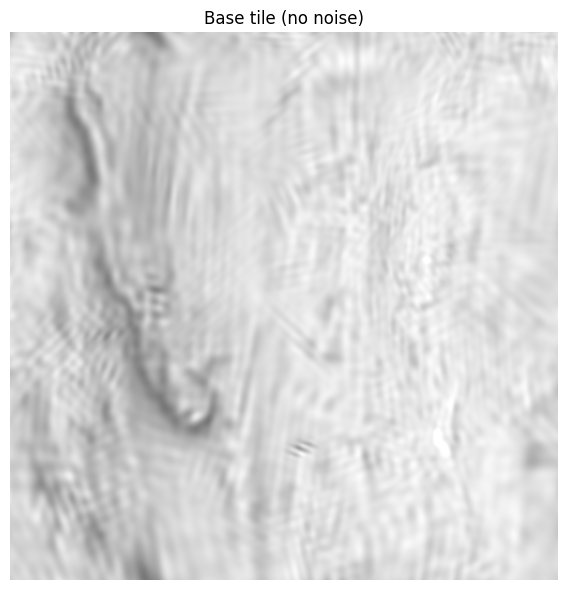

In [4]:
base_image = render_gabor_image(
    TILE_SIZE,
    base_model._means,
    base_model._frequencies,
    base_model._colors,
    base_model._colors2,
    base_model._opacities,
    base_model._scales,
    base_model._rotations,
    gnr.device,
).clamp(0, 1).detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(base_image)
plt.title("Base tile (no noise)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Noise injection helper

Given the base model's parameter tensors, we add independent Gaussian noise to
each parameter. The `NOISE_STD` dict controls the magnitude per parameter.

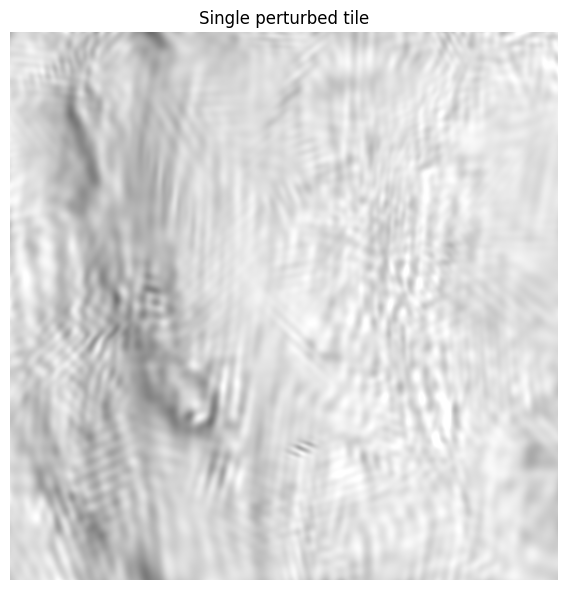

In [5]:
def perturb_params(base_model, noise_std: dict, n_prims: int):
    """Return a dict of noisy parameter tensors (detached, on device).

    Only the parameters listed in `noise_std` keys are perturbed. All other
    parameters (e.g. colors) are copied verbatim from the base model.
    """
    all_params = ["means", "colors", "colors2", "frequencies",
                  "opacities", "scales", "rotations"]
    params = {}
    for name in all_params:
        base = getattr(base_model, "_" + name).data.clone()
        if name in noise_std:
            params[name] = base + noise_std[name] * torch.randn_like(base)
        else:
            params[name] = base  # unperturbed (e.g. colors left alone)
    return params


def render_from_params(params, kernel_size, device):
    """Render a Gabor image from a raw parameter dict."""
    return render_gabor_image(
        kernel_size=kernel_size,
        means=params["means"],
        frequencies=params["frequencies"],
        colors=params["colors"],
        colors2=params["colors2"],
        opacities=params["opacities"],
        scales=params["scales"],
        rotations=params["rotations"],
        device=device,
    ).clamp(0, 1).detach().cpu().numpy()


# Quick sanity check: perturb once and render
test_params = perturb_params(base_model, NOISE_STD, n_prims)
test_img = render_from_params(test_params, TILE_SIZE, gnr.device)
plt.figure(figsize=(6, 6))
plt.imshow(test_img)
plt.title("Single perturbed tile")
plt.axis("off")
plt.tight_layout()
plt.show()

## 5. Render all tiles

We render one tile per grid cell. Each tile gets its own independent noise
sample so adjacent tiles look different but share the same global structure.

In [6]:
tiles = np.zeros((GRID_ROWS, GRID_COLS, TILE_SIZE, TILE_SIZE, 3), dtype=np.float32)

total = GRID_ROWS * GRID_COLS
for row in range(GRID_ROWS):
    for col in range(GRID_COLS):
        idx = row * GRID_COLS + col + 1
        print(f"  Rendering tile ({row},{col})  [{idx}/{total}] ...", end=" ")
        params = perturb_params(base_model, NOISE_STD, n_prims)
        tiles[row, col] = render_from_params(params, TILE_SIZE, gnr.device)
        print("done")

print(f"\nAll {total} tiles rendered.  shape per tile: {tiles.shape[2:4]}")

  Rendering tile (0,0)  [1/16] ... done
  Rendering tile (0,1)  [2/16] ... done
  Rendering tile (0,2)  [3/16] ... done
  Rendering tile (0,3)  [4/16] ... done
  Rendering tile (1,0)  [5/16] ... done
  Rendering tile (1,1)  [6/16] ... done
  Rendering tile (1,2)  [7/16] ... done
  Rendering tile (1,3)  [8/16] ... done
  Rendering tile (2,0)  [9/16] ... done
  Rendering tile (2,1)  [10/16] ... done
  Rendering tile (2,2)  [11/16] ... done
  Rendering tile (2,3)  [12/16] ... done
  Rendering tile (3,0)  [13/16] ... done
  Rendering tile (3,1)  [14/16] ... done
  Rendering tile (3,2)  [15/16] ... done
  Rendering tile (3,3)  [16/16] ... done

All 16 tiles rendered.  shape per tile: (512, 512)


## 6. Display all tiles in a grid

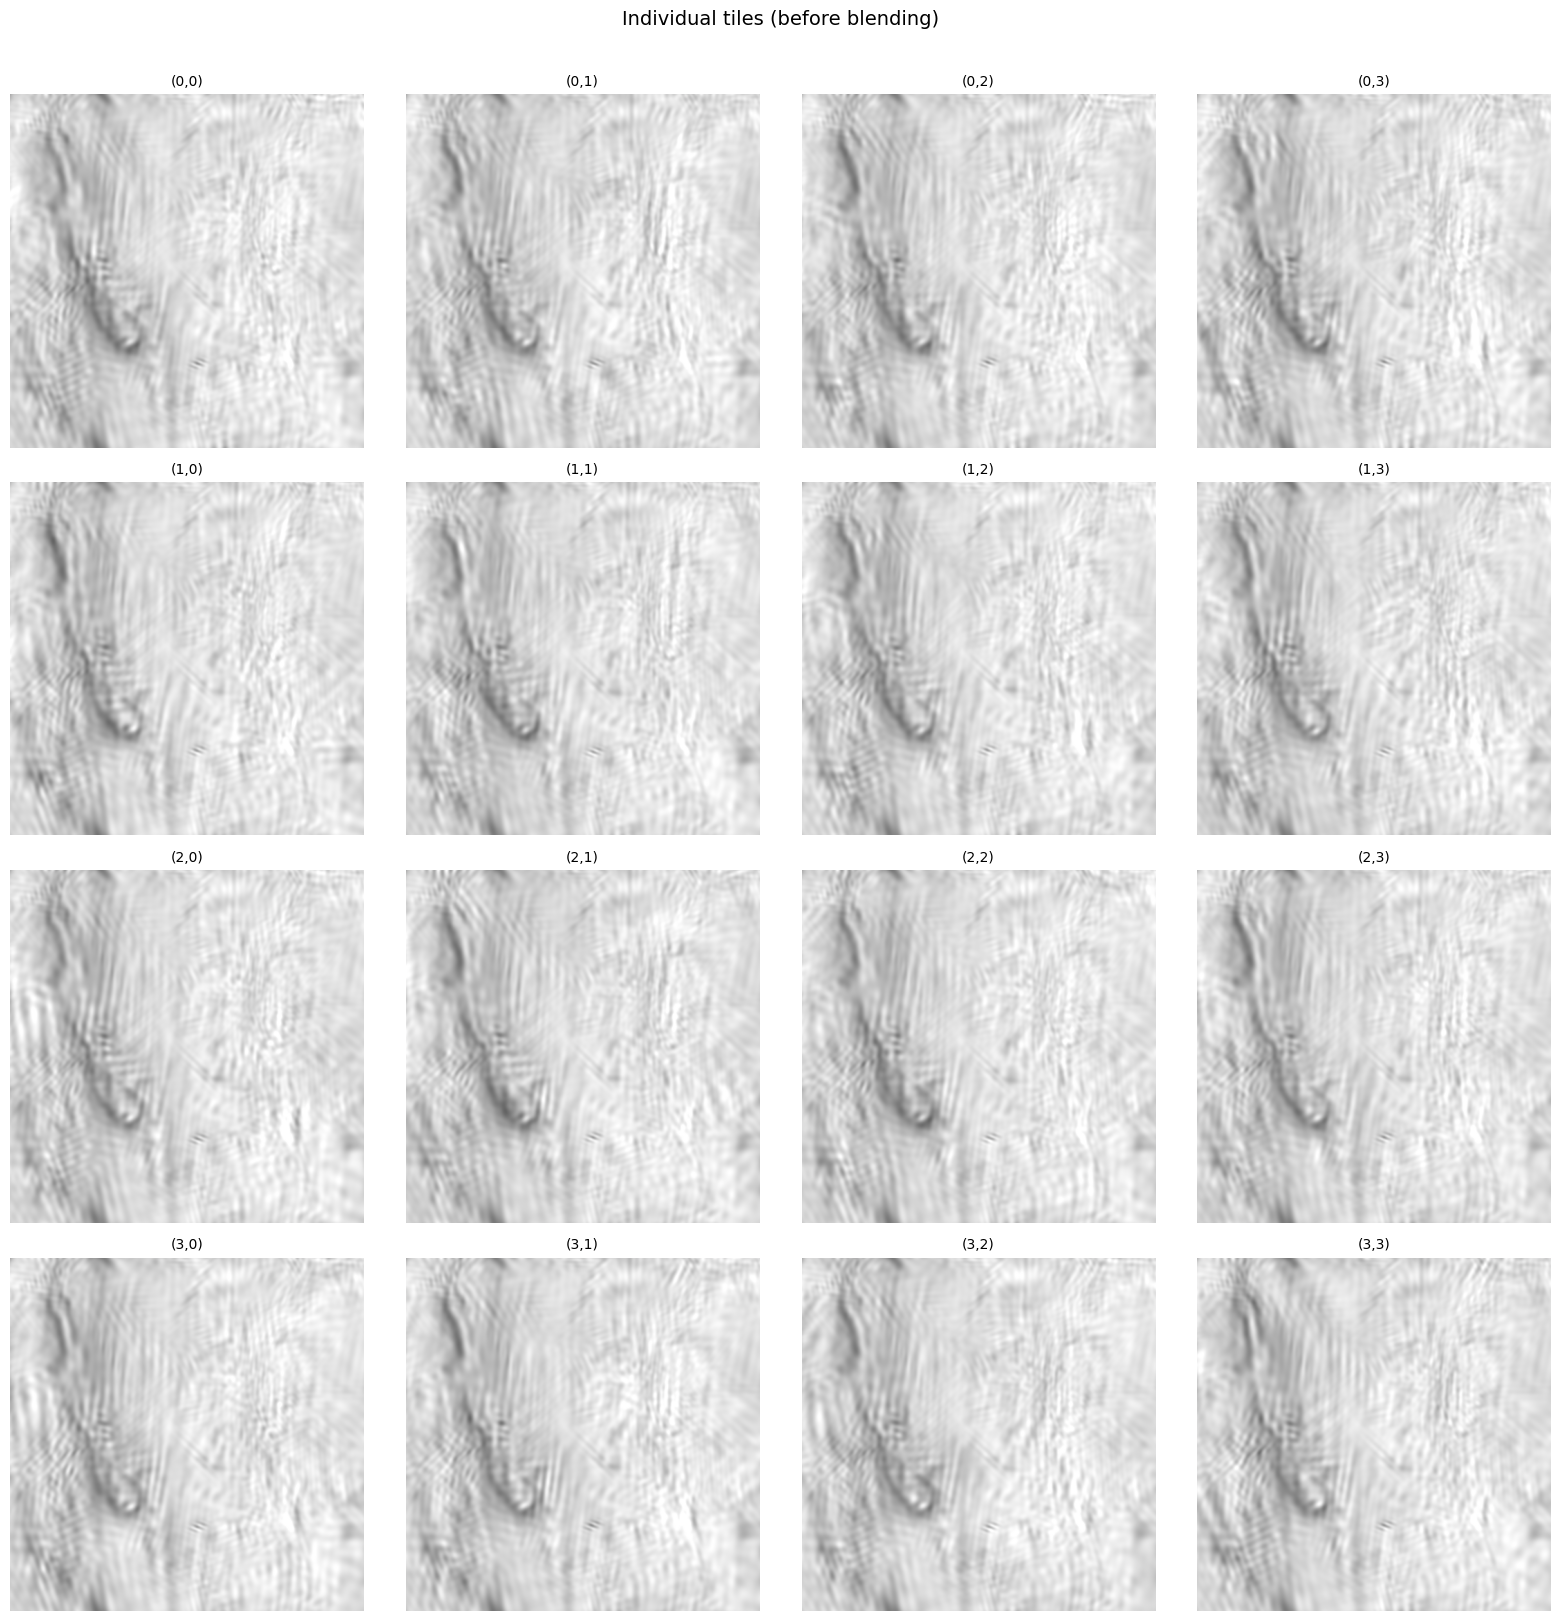

In [7]:
fig, axes = plt.subplots(GRID_ROWS, GRID_COLS,
                         figsize=(4 * GRID_COLS, 4 * GRID_ROWS),
                         squeeze=False)
for row in range(GRID_ROWS):
    for col in range(GRID_COLS):
        axes[row, col].imshow(tiles[row, col])
        axes[row, col].set_title(f"({row},{col})", fontsize=10)
        axes[row, col].axis("off")
plt.suptitle("Individual tiles (before blending)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Progressive Gaussian seam blur (0 overlap)

Poisson blending (`seamlessClone`) turned out to be a poor fit for this Gabor
noise: on self-similar, mostly-flat noise the solver reconstructs gradients and
injects extra high-frequency variation near seams, making the join *rougher* than
a plain average. A fixed band of Gaussian blur helps but softens a wide area.

Instead we use a **progressive seam blur**:

1. Lay the tiles out with **zero overlap** - they butt edge to edge, leaving a
   hard seam line.
2. For each of `N_BLUR_ITERS` passes `i = 0..N-1`, apply a Gaussian blur using a
   kernel of size `2*i + 3` (so 3, 5, 7, ...) and sigma `SIGMA_1 + i`, but apply it
   **only inside a band around each seam line whose half-width grows with the
   kernel** as `(kernel // 2) * BAND_SCALE`.

The small kernels blend the immediate seam line first (a tightly feathered join),
then each larger kernel pushes the blend zone a little further out and smooths it
more. The result is a seam that transitions gradually from fully-blended (at the
line) to untouched texture (further away), without a single heavy blur over the
whole tile.

### Why no black regions

With 0 overlap every tile covers a unique region, so the canvas is fully filled by
construction and there is nothing to collapse to black.


In [8]:
def naive_composite(tiles, stride_px):
    """Place all tiles, averaging any overlapping regions.

    Kept for comparison. With OVERLAP_FRAC = 0 the overlap is empty, so this
    reduces to a plain hard paste (edge-to-edge tiles).
    """
    R, C, H, W, _ = tiles.shape
    canvas_h = stride_px * (R - 1) + H
    canvas_w = stride_px * (C - 1) + W

    acc = np.zeros((canvas_h, canvas_w, 3), dtype=np.float32)
    counts = np.zeros((canvas_h, canvas_w, 1), dtype=np.float32)

    for row in range(R):
        for col in range(C):
            y0 = row * stride_px
            x0 = col * stride_px
            acc[y0:y0+H, x0:x0+W] += tiles[row, col]
            counts[y0:y0+H, x0:x0+W] += 1

    return acc / np.maximum(counts, 1)


def _seam_band_mask(canvas_h, canvas_w, stride_px, half_width):
    """Float weight mask (1 inside a half_width band around seams, 0 outside)."""
    mask = np.zeros((canvas_h, canvas_w), dtype=np.float32)
    for sx in range(stride_px, canvas_w, stride_px):
        mask[:, max(0, sx - half_width):min(canvas_w, sx + half_width)] += 1
    for sy in range(stride_px, canvas_h, stride_px):
        mask[max(0, sy - half_width):min(canvas_h, sy + half_width), :] += 1
    return np.clip(mask, 0, 1)[..., None]


def progressive_seam_blur(tiles, stride_px, sigma_1, n_iters, band_scale):
    """Stitch tiles with 0 overlap and dissolve the seams progressively.

    Tiles are pasted edge to edge. Then, for each pass i, a Gaussian blur with
    kernel size (2*i+3) and sigma (sigma_1 + i) is applied only within a band of
    half-width (2*i+3)//2 * band_scale around every seam line. Because the band
    and kernel both grow each pass, the blend zone extends outward from the seam
    gradually instead of being a single fixed-width blur.

    Parameters
    ----------
    tiles : ndarray, shape (R, C, H, W, 3), float32 [0,1]
    stride_px : int, pixel stride between tile origins (equal to tile size
                for 0 overlap)
    sigma_1 : float, base Gaussian sigma for the first (smallest) pass
    n_iters : int, number of blur passes
    band_scale : float, band half-width grows as (kernel//2)*band_scale

    Returns
    -------
    canvas : ndarray, shape (canvas_H, canvas_W, 3), float32 [0,1]
    """
    R, C, H, W, _ = tiles.shape
    canvas_h = stride_px * (R - 1) + H
    canvas_w = stride_px * (C - 1) + W

    canvas = np.zeros((canvas_h, canvas_w, 3), dtype=np.float32)
    for row in range(R):
        for col in range(C):
            y0 = row * stride_px
            x0 = col * stride_px
            canvas[y0:y0+H, x0:x0+W] = tiles[row, col]

    for i in range(n_iters):
        ksize = int(2 * i + 3)          # 3, 5, 7, ...
        sigma = sigma_1 + i*SIGMA_COEFFICIENT
        half_width = int((ksize // 2) * band_scale)
        blurred = cv2.GaussianBlur(canvas, (ksize, ksize), sigma)
        mask = _seam_band_mask(canvas_h, canvas_w, stride_px, half_width)
        canvas = canvas * (1.0 - mask) + blurred * mask

    return canvas


print("Stitching tiles with progressive Gaussian seam blur...")
canvas = progressive_seam_blur(tiles, STRIDE_PX, SIGMA_1, N_BLUR_ITERS, BAND_SCALE)
print(f"Done.  Canvas shape: {canvas.shape}  dtype: {canvas.dtype}")

black_frac = float((canvas.max(axis=-1) < 0.05).mean())
print(f"Black-pixel fraction: {black_frac*100:.3f}%")


Stitching tiles with progressive Gaussian seam blur...
Done.  Canvas shape: (2048, 2048, 3)  dtype: float32
Black-pixel fraction: 0.000%


## 8. Hard paste (no seam blur) for comparison

To show what the progressive blur removes, we also produce a canvas with only the
plain edge-to-edge paste (0 overlap, no blurring). This has a hard discontinuity
along every tile boundary.


In [9]:
def naive_tile_stitch(tiles, stride_px):
    """Composite tiles onto canvas with plain edge-to-edge paste, no seam blur."""
    return naive_composite(tiles, stride_px)


naive_canvas = naive_tile_stitch(tiles, STRIDE_PX)
print(f"Naive canvas shape: {naive_canvas.shape}")

Naive canvas shape: (2048, 2048, 3)


## 9. Side-by-side comparison

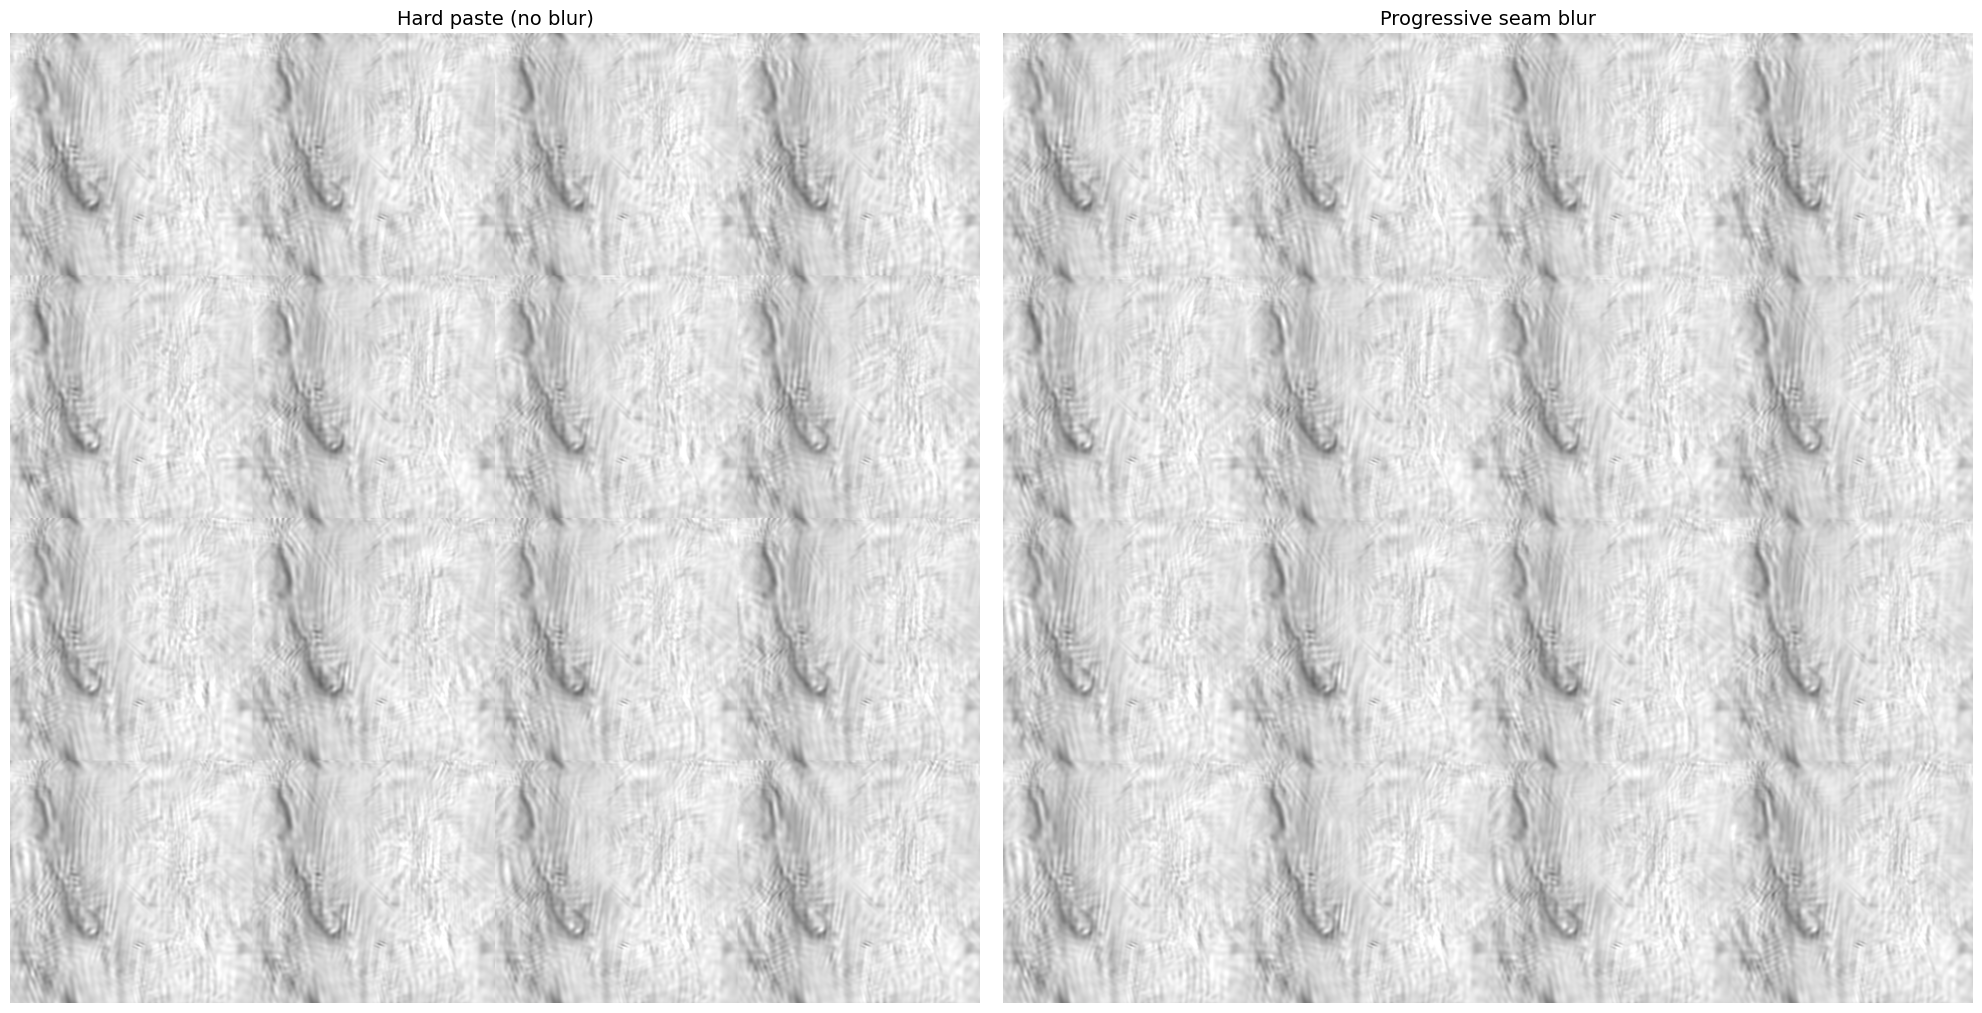

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10), squeeze=False)

axes[0, 0].imshow(naive_canvas)
axes[0, 0].set_title("Hard paste (no blur)", fontsize=14)
axes[0, 0].axis("off")

axes[0, 1].imshow(canvas)
axes[0, 1].set_title("Progressive seam blur", fontsize=14)
axes[0, 1].axis("off")

plt.tight_layout()
plt.show()

## 10. Zoom into a seam to inspect blending quality

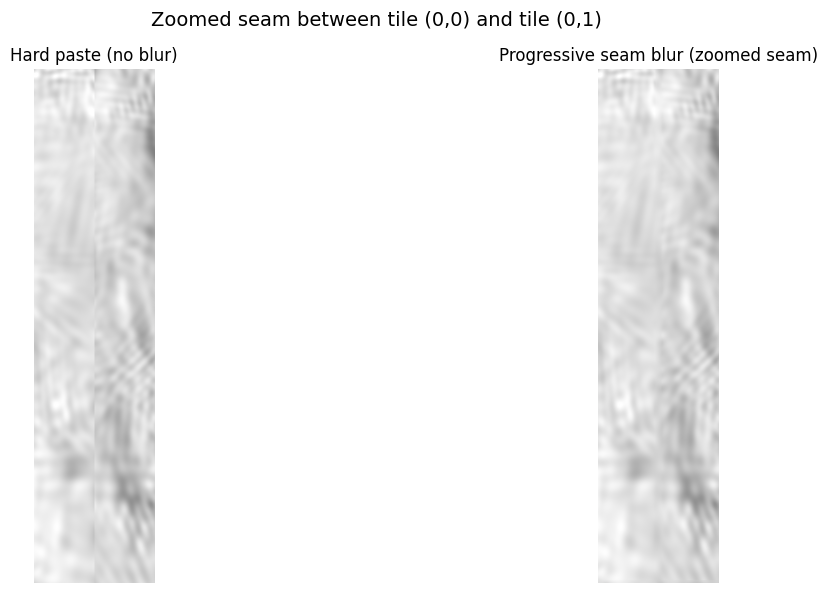

In [11]:
# zoom into the seam between tile (0,0) and tile (0,1)
# seam region: x from (TILE_SIZE - OVERLAP_PX) to TILE_SIZE
seam_x_center = TILE_SIZE - OVERLAP_PX // 2
zoom_half = OVERLAP_PX + 60  # extra context on each side

x0 = max(seam_x_center - zoom_half, 0)
x1 = min(seam_x_center + zoom_half, naive_canvas.shape[1])
y0 = 0
y1 = min(TILE_SIZE, naive_canvas.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), squeeze=False)

axes[0, 0].imshow(naive_canvas[y0:y1, x0:x1])
axes[0, 0].set_title("Hard paste (no blur)", fontsize=12)
axes[0, 0].axis("off")

axes[0, 1].imshow(canvas[y0:y1, x0:x1])
axes[0, 1].set_title("Progressive seam blur (zoomed seam)", fontsize=12)
axes[0, 1].axis("off")

plt.suptitle("Zoomed seam between tile (0,0) and tile (0,1)", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Parameter noise sensitivity sweep

How does the noise magnitude affect the result? We render a 3 x 3 grid at
three noise levels (low, medium, high) to build intuition.

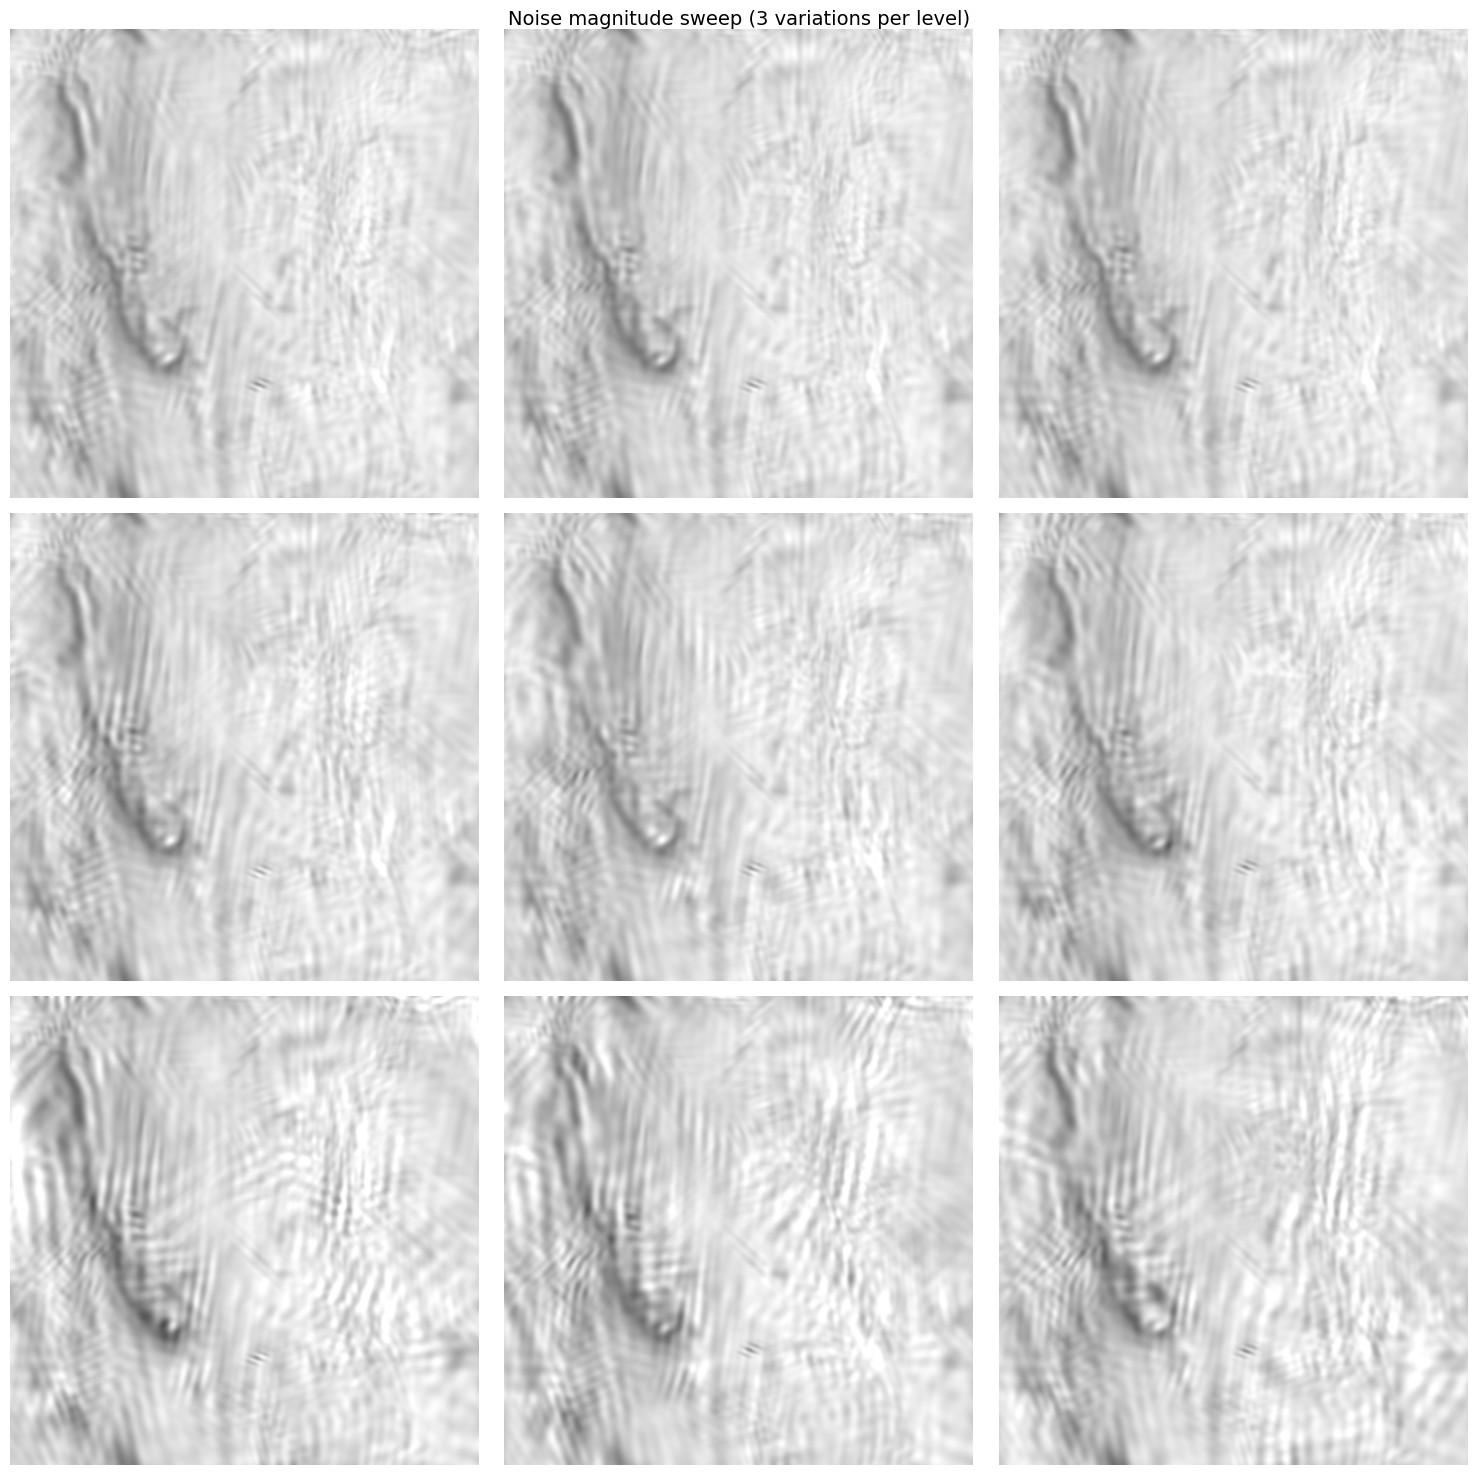

In [12]:
SWEEP_ROWS = 3
SWEEP_COLS = 3

noise_levels = {
    "Low (0.5x)":  {k: v * 0.5 for k, v in NOISE_STD.items()},
    "Medium (1x)":  NOISE_STD.copy(),
    "High (2x)":   {k: v * 2.0 for k, v in NOISE_STD.items()},
}

fig, axes = plt.subplots(
    len(noise_levels), SWEEP_COLS,
    figsize=(5 * SWEEP_COLS, 5 * len(noise_levels)),
    squeeze=False,
)

for level_idx, (level_name, level_std) in enumerate(noise_levels.items()):
    for col in range(SWEEP_COLS):
        params = perturb_params(base_model, level_std, n_prims)
        img = render_from_params(params, TILE_SIZE, gnr.device)
        axes[level_idx, col].imshow(img)
        axes[level_idx, col].axis("off")
        if col == 0:
            axes[level_idx, col].set_ylabel(level_name, fontsize=12, rotation=0,
                                           labelpad=80, va="center")

plt.suptitle("Noise magnitude sweep (3 variations per level)", fontsize=14)
plt.tight_layout()
plt.show()

## 12. Save the final output

In [13]:
out_path = Path("gabor_tiling_output.png")
rgb_out = (np.clip(canvas, 0, 1) * 255).astype(np.uint8)
plt.imsave(str(out_path), rgb_out)
print(f"Saved tiled output to {out_path}  ({rgb_out.shape[1]}x{rgb_out.shape[0]} px)")

Saved tiled output to gabor_tiling_output.png  (2048x2048 px)
